In [1]:
from sunpy.map import Map, all_coordinates_from_map
from astropy.io import fits
import matplotlib.pyplot as plt
import os
import numpy as np
from datetime import datetime

In [2]:
def removenan(im, key=0):
    """
    remove NAN and INF in an image
    """
    im2 = np.copy(im)
    arr = np.isnan(im2)
    im2[arr] = key
    arr2 = np.isinf(im2)
    im2[arr2] = key

    return im2

def disk(M, N, r0):
    X, Y = np.meshgrid(np.arange(int(-(N / 2)), int(N / 2)), np.linspace(-int(M / 2), int(M / 2) - 1, M))
    r = (X) ** 2 + (Y) ** 2
    r = (r ** 0.5)
    im = r < r0
    return im

In [3]:
def limbdarkening(s_map, limb_offset=0.99):

    coords = all_coordinates_from_map(s_map)
    radial_distance = (np.sqrt(coords.Tx ** 2 + coords.Ty ** 2) / s_map.rsun_obs).value
    radial_distance[radial_distance >= limb_offset] = np.NaN
    ideal_correction = np.cos(radial_distance * np.pi / 2)

    condition = np.logical_not(np.isnan(np.ravel(ideal_correction)))
    map_list = np.ravel(s_map.data)[condition]
    correction_list = np.ravel(ideal_correction)[condition]

    fit = np.polyfit(correction_list, map_list, 4)
    poly_fit = np.poly1d(fit)

    map_correction = poly_fit(ideal_correction)
    corrected_map = s_map.data / map_correction

    solar_disk_rlimb = corrected_map[radial_distance < limb_offset]

    return corrected_map, solar_disk_rlimb.mean(), solar_disk_rlimb.std()

def removelimb(im, center=None, RSUN=None):
  #  pip install polarTransform
    import polarTransform as pT
    from scipy import signal

    radiusSize, angleSize = 1024, 180
    im = removenan(im)
    im2=im.copy()
    if center is None:
        T = (im.max() - im.min()) * 0.2 + im.min()
        arr = (im > T)
        import scipy.ndimage.morphology as snm
        arr=snm.binary_fill_holes(arr)
#        im2=(im-T)*arr
        Y, X = np.mgrid[:im.shape[0], :im.shape[1]]
        xc = (X * arr).astype(float).sum() / (arr*1).sum()
        yc = (Y * arr).astype(float).sum() / (arr*1).sum()
        center = (xc, yc)
        RSUN = np.sqrt(arr.sum() / np.pi)

    Disk = np.int8(disk(im.shape[0], im.shape[1], RSUN * 0.95))
    impolar, Ptsetting = pT.convertToPolarImage(im, center, radiusSize=radiusSize, angleSize=angleSize)
    profile = np.median(impolar, axis=0)
    profile = signal.savgol_filter(profile, 21, 5)
    Z = profile.reshape(-1, 1).T.repeat(impolar.shape[0], axis=0)
    limb=Ptsetting.convertToCartesianImage(Z)
#    im2 = removenan(im / Ptsetting.convertToCartesianImage(Z))-1
#    im2 = im2 * Disk
    im = removenan(im /limb)
  #  im= im*Disk
    return im, center, RSUN, profile,limb

In [4]:
def black_mask(s_map, value, limb_offset=0.99):

    coords = all_coordinates_from_map(s_map)
    radial_distance = np.sqrt(coords.Tx ** 2 + coords.Ty ** 2) / s_map.rsun_obs.value
    radial_distance = radial_distance.value

    s_map_data = s_map.data.copy()
    s_map_data = s_map.data.astype(np.float32)

    s_map_data[radial_distance >= limb_offset] = value

    solar_disk = s_map_data[radial_distance < limb_offset]

    return s_map_data, solar_disk.mean(), solar_disk.std()


In [5]:
def kso_1920_editor(fits_1920_dir):
    with fits.open(fits_1920_dir, mode='update') as hdul:
        header = hdul[0].header

        header['CUNIT1'] = 'arcsec'
        header['CUNIT2'] = 'arcsec'

        original_date = header.get('DATE-OBS', None)
        if original_date:
            try:
                datetime.strptime(original_date, '%Y-%m-%dT%H:%M:%SZ')
                print(f"DATE-OBS already in standard format: {original_date}")
            except ValueError:
                try:
                    parsed_time = datetime.strptime(original_date, '%d-%m-%YT%H:%M')
                    standard_time = parsed_time.strftime('%Y-%m-%dT%H:%M:%SZ')
                    header['DATE-OBS'] = standard_time
                    print(f"DATE-OBS updated to standard format: {standard_time}")
                except ValueError:
                    print(f"Warning: Unable to parse DATE-OBS: {original_date}")

        hdul.flush()

def kso_1970_editor(fits_1970_dir):
    with fits.open(fits_1970_dir, mode='update') as hdul1:
        header1 = hdul1[0].header

        header1['CUNIT1'] = 'arcsec'
        header1['CUNIT2'] = 'arcsec'

        solar_r = header1.get('SOLAR_R', None)
        cdelt = header1.get('CDELT1', None)

        if solar_r * cdelt > 1025:
            print(f"Already Corrected!")
            return

        header1['SOLAR_R'] = solar_r * cdelt

        hdul1.flush()

In [6]:
with fits.open(r'/home/jhpan/ITI/InstrumentToInstrument/HA_19230219T082100_cal.fits', mode='update') as hdul:
    header = hdul[0].header
header

SIMPLE  =                    T /image conforms to FITS standard                 
BITPIX  =                  -32 /bits per data value                             
NAXIS   =                    2 /number of axes                                  
NAXIS1  =                 4096 /                                                
NAXIS2  =                 4096 /                                                
EXTEND  =                    T /file may contain extensions                     
ORIGIN  = 'KODAIKANAL OBSERVATORY' /                                            
TELESCOP= 'SPECTROHELIOGRAPH'  /                                                
OBJECT  = 'SUN     '           /                                                
DATE-OBS= '19-02-1923T08:21'   /                                                
ROT_ANGL=       -397.718918618 /                                                
MANUAL_R=       -179.226610925 /                                                
AUTOMATI=       -218.4923076

In [7]:
with fits.open('/home/jhpan/ITI/InstrumentToInstrument/0010086_Ha19730511_081400.fts', mode='update') as hdul1:
    header1 = hdul1[0].header

    solar_r = header1.get('SOLAR_R', None)
    cdelt = header1.get('CDELT1', None)

    header1['SOLAR_R'] = solar_r * cdelt

    hdul1.flush()


In [8]:
with fits.open('/home/jhpan/ITI/InstrumentToInstrument/0010086_Ha19730511_081400.fts', mode='update') as hdul2:
    header2 = hdul2[0].header
header2

SIMPLE  =                    T                                                  
BITPIX  =                    8                                                  
NAXIS   =                    3                                                  
NAXIS1  =                 1024                                                  
NAXIS2  =                 1024                                                  
NAXIS3  =                    2                                                  
BUNIT   = 'CCD COUNTS'                                                          
BSCALE  =                    1                                                  
BZERO   =                    0                                                  
DATAMIN =                    0                                                  
DATAMAX =                  212                                                  
CTYPE1  = 'SOLAR_X ' / [arcsec/px]                                              
CTYPE2  = 'SOLAR_Y ' / [arcs

2014 KSO data Sample

In [9]:
fits_2014 = '/home/jhpan/ITI/InstrumentToInstrument/dataset/2017_fits/kanz_halph_fd_20170101_082518.fts.gz'
smap_2014 = Map(fits_2014)

In [10]:
smap_2014.meta["waveunit"] = "angstrom"
smap_2014.fits_header

SIMPLE  =                    T                                                  
BITPIX  =                   16                                                  
NAXIS   =                    2                                                  
NAXIS1  =                 2048                                                  
NAXIS2  =                 2048                                                  
BUNIT   = 'CCD COUNTS'                                                          
BSCALE  =                  1.0                                                  
BZERO   =              32768.0                                                  
DATAMIN =                    0                                                  
DATAMAX =                  742                                                  
CTYPE1  = 'SOLAR_X '                                                            
CTYPE2  = 'SOLAR_Y '                                                            
CUNIT1  = 'arcsec  '        

In [11]:
data_2014, mean_2014, std_2014 = limbdarkening(smap_2014)
data_2014_o, mean_2014_o, std_2014_o = black_mask(smap_2014, np.nan)

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,crlt_obs,dsun_obs
 [sunpy.map.mapbase]


In [12]:
data_2014.shape

(2048, 2048)

(-0.5, 2047.5, 2047.5, -0.5)

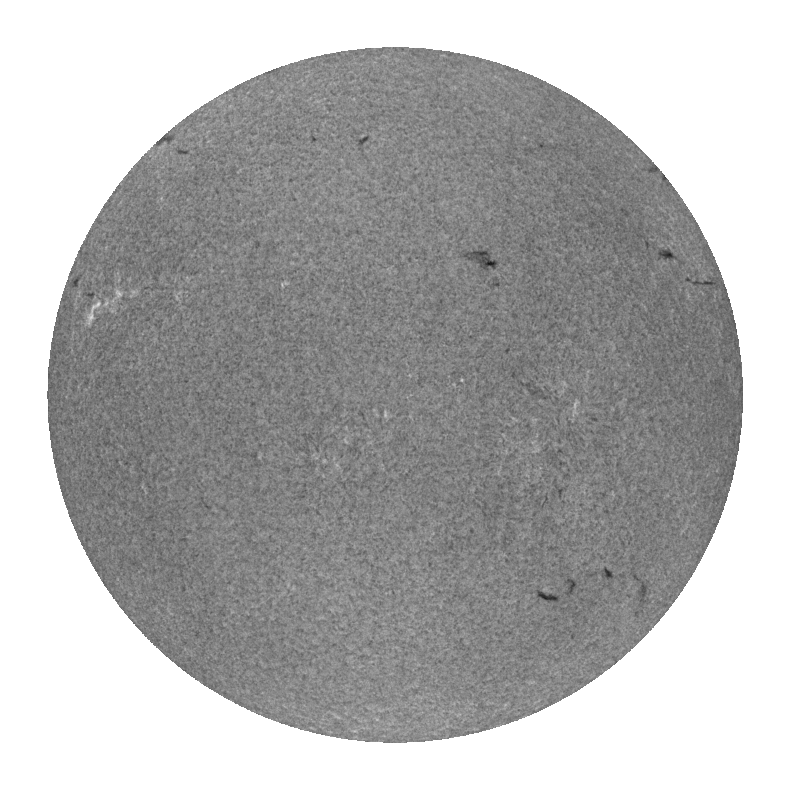

In [13]:
fig = plt.figure(figsize=(10, 10))
plt.imshow(np.flipud(data_2014), cmap='gray')
plt.axis('off')

1920 limb darkening sample

In [17]:
from sunpy.map import Map

fits_1921_smaple = r'/home/jhpan/ITI/InstrumentToInstrument/HA_19230219T082100_cal.fits'
kso_1920_editor(fits_1921_smaple)
smap = Map(fits_1921_smaple)

DATE-OBS updated to standard format: 1923-02-19T08:21:00Z


In [18]:
smap_limb, limb_mean, limb_std = limbdarkening(smap)
smap_black, _, _ = black_mask(smap, np.nan)

For frame 'heliographic_stonyhurst' the following metadata is missing: hglt_obs,hgln_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,crlt_obs,dsun_obs
 [sunpy.map.mapbase]
/home/jhpan/.local/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/jhpan/.local/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/jhpan/.local/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/jhpan/.local/lib/python3.11/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{fun

In [19]:
smap_limb.shape

(4096, 4096)

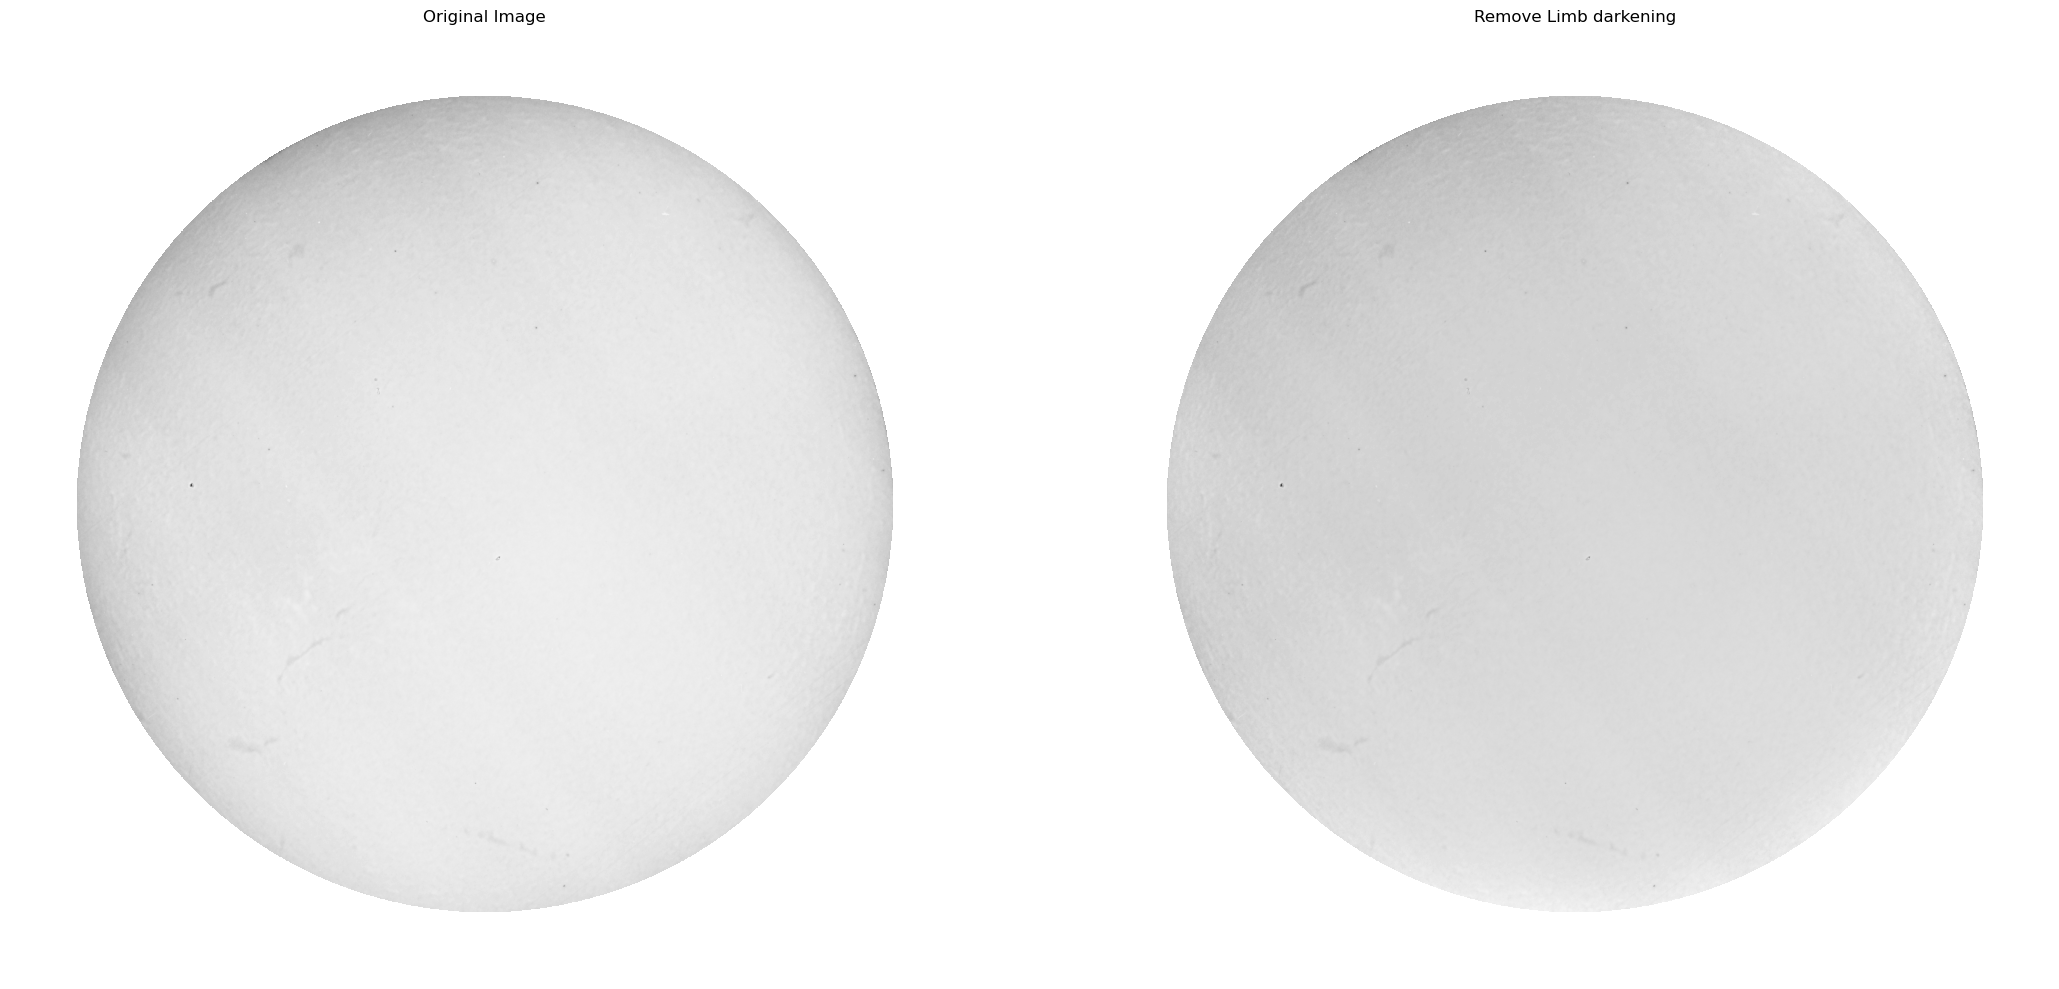

In [20]:
fig= plt.figure(figsize=(22, 10))
ax1 = fig.add_subplot(1, 2, 1)
# ax.imshow(smap.data, cmap='gray')
ax1.imshow(smap_black, cmap='gray')
ax1.set_title('Original Image')
plt.axis('off')

ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(smap_limb, cmap='gray')
ax2.set_title('Remove Limb darkening')
plt.axis('off')

plt.tight_layout()
# plt.savefig(os.path.basename(fits_1921_smaple).replace('fits', 'png'), dpi=100)
plt.show()

Batch process headers for 1920

In [ ]:
from tqdm import tqdm
fits_2014_direction = r'/home/jhpan/ITI/InstrumentToInstrument/dataset/2014_fits'
fits_2014_list = os.listdir(fits_2014_direction)

for filename in tqdm(fits_2014_list):
    file = os.path.join(fits_2014_direction, filename)
    kso_1920_editor(file)

In [231]:
fits_2020 = '/database2/jhpan/iti/high_fits/kanz_halph_fd_20250624_062439.fts.gz'
smap_2020 = Map(fits_2020)
smap_2020.meta["waveunit"] = "angstrom"
smap_2020.fits_header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                   16 / number of bits per data pixel                  
NAXIS   =                    2 / number of data axes                            
NAXIS1  =                 2048 / length of data axis 1                          
NAXIS2  =                 2048 / length of data axis 2                          
EXTEND  =                    T / FITS dataset may contain extensions            
FILENAME= 'kanz_halph_fd_20250624_062439.fts.gz'                                
DATE    = '2025-06-24T07:23:22' / file creation date (YYYY-MM-DDThh:mm:ss UT)   
DATE_OBS= '2025-06-24T06:24:39Z' / Date of observation                          
DATE-OBS= '2025-06-24T06:24:39' / Date of observation                           
DATE-BEG= '2025-06-24T06:24:39' / Date of observation                           
TIMESYS = 'UTC     '                                                            
OBSVTRY = 'Kanzelhoehe Obser

In [232]:
data_2020, _, _ = limbdarkening(smap_2020)

For frame 'heliographic_stonyhurst' the following metadata is missing: hgln_obs,hglt_obs,dsun_obs
For frame 'heliographic_carrington' the following metadata is missing: crln_obs,dsun_obs,crlt_obs
 [sunpy.map.mapbase]


(-0.5, 2047.5, 2047.5, -0.5)

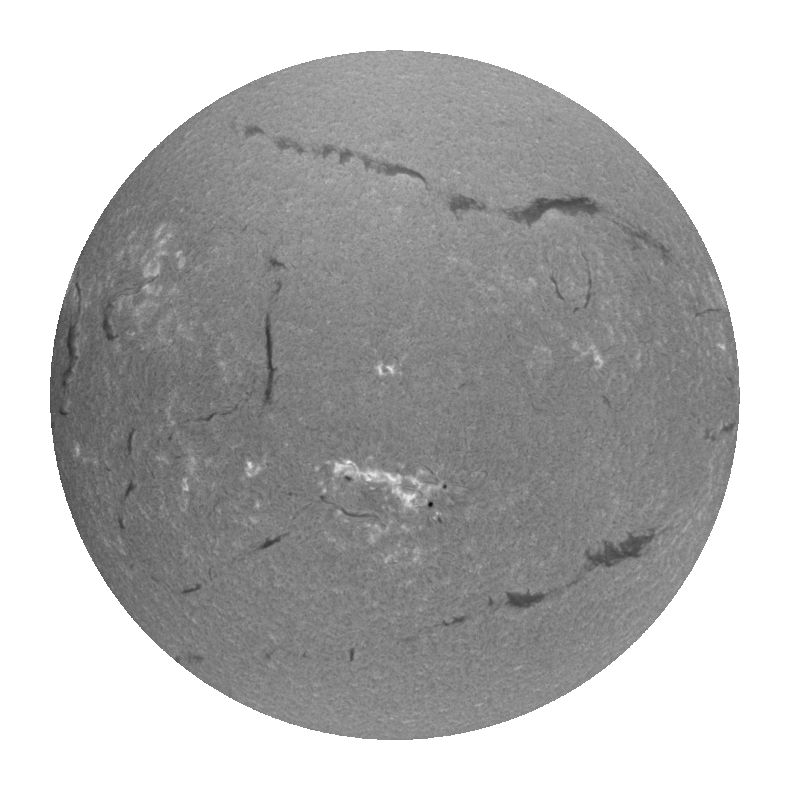

In [233]:
fig = plt.figure(figsize=(10, 10))
plt.imshow(np.flipud(data_2020), cmap='gray')
plt.axis('off')

In [241]:
test_1920 = r'/home/jhpan/ITI/InstrumentToInstrument/dataset/1920_fits/HA_19200106T092200_cal.fits'
with fits.open(test_1920, mode='update') as hdult:
    headert = hdult[0].header
headert

SIMPLE  =                    T /image conforms to FITS standard                 
BITPIX  =                  -32 /bits per data value                             
NAXIS   =                    2 /number of axes                                  
NAXIS1  =                 4096 /                                                
NAXIS2  =                 4096 /                                                
EXTEND  =                    T /file may contain extensions                     
ORIGIN  = 'KODAIKANAL OBSERVATORY' /                                            
TELESCOP= 'SPECTROHELIOGRAPH'  /                                                
OBJECT  = 'SUN     '           /                                                
DATE-OBS= '1920-06-01T09:22:00Z'                                                
ROT_ANGL=       -400.197536564 /                                                
MANUAL_R=       -179.750477740 /                                                
AUTOMATI=       -220.4470588

In [24]:
fits_1920_direction = r'/database2/jhpan/iti/low_fits'
fits_1920_list = os.listdir(fits_1920_direction)

for i,filename in enumerate(fits_1920_list):
    print(i)
    fits_1920 = os.path.join(fits_1920_direction, filename)
    kso_1920_editor(fits_1920)

0
DATE-OBS already in standard format: 1924-12-01T07:53:00Z
1
DATE-OBS already in standard format: 1924-11-30T09:04:00Z
2
DATE-OBS already in standard format: 1924-12-31T07:59:00Z
3
DATE-OBS already in standard format: 1924-11-26T07:55:00Z
4
DATE-OBS already in standard format: 1924-12-30T08:09:00Z
5
DATE-OBS already in standard format: 1924-11-29T08:42:00Z
6
DATE-OBS already in standard format: 1924-12-29T08:22:00Z
7
DATE-OBS already in standard format: 1924-11-27T15:00:00Z
8
DATE-OBS already in standard format: 1924-12-29T07:47:00Z
9
DATE-OBS already in standard format: 1924-11-29T08:05:00Z
10
DATE-OBS already in standard format: 1924-12-28T08:18:00Z
11
DATE-OBS already in standard format: 1924-11-25T08:00:00Z
12
DATE-OBS already in standard format: 1924-12-27T07:57:00Z
13
DATE-OBS already in standard format: 1924-11-25T08:39:00Z
14
DATE-OBS already in standard format: 1924-12-26T08:14:00Z
15
DATE-OBS already in standard format: 1924-11-19T09:19:00Z
16
DATE-OBS already in standard fo

In [240]:
len(fits_1920_list)

235

In [33]:
import torch, matplotlib.pyplot as plt
from itipy.data.dataset import BaseDataset
from train_1920_2017_0_test import Low1920

GEN_PATH   = "low_to_high_kso/generator_AB.pt"
LOW_DATA   = "/home/jhpan/ITI/InstrumentToInstrument/dataset/1920_fits"

gen_ab = torch.load(GEN_PATH, map_location="cuda")
gen_ab.eval()

low_ds = Low1920(LOW_DATA, resolution=512, limit=4)
samples = [low_ds[i].unsqueeze(0) for i in range(len(low_ds))]  # [B=1, C, H, W]
batch   = torch.cat(samples, 0).cuda().float()

with torch.no_grad():
    fake_high = gen_ab(batch) # shape (B, 1, 512, 512)
n = fake_high.size(0)
plt.figure(figsize=(4*n, 6))
for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(batch[i,0].cpu(), cmap='gray'); plt.axis('off'); plt.title(f"Low {i}")
    plt.subplot(2, n, i+1+n)
    plt.imshow(fake_high[i,0].cpu(), cmap='gray'); plt.axis('off'); plt.title(f"FakeHigh {i}")
plt.tight_layout();  plt.show()


ModuleNotFoundError: No module named 'tensorboard'

View Train_loss

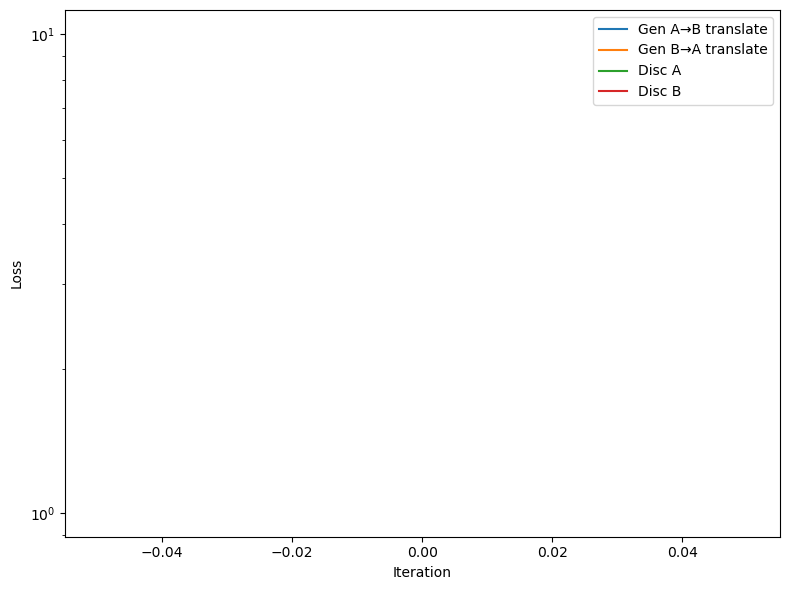

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = r"/home/jhpan/ITI/InstrumentToInstrument/low_to_high_kso/history/train_loss.csv"

df = pd.read_csv(csv_path)

plt.figure(figsize=(8,6))
plt.plot(df['iteration'], df['loss_gen_a_translate'], label='Gen A→B translate')
plt.plot(df['iteration'], df['loss_gen_b_translate'], label='Gen B→A translate')
plt.plot(df['iteration'], df['loss_dis_a']        , label='Disc A')
plt.plot(df['iteration'], df['loss_dis_b']        , label='Disc B')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()
